In [38]:
import os
%cd ~/erc-src/cuneiform-ocr/
os.getcwd()

%load_ext autoreload
%autoreload 2

import sys
import os

# Import broken sign filter and sign resolver
from data_processing.broken_sign_filter import filter_broken_from_text
from data_processing.sign_resolver import SignToABZResolver

# MongoDB URI for SignToABZResolver
from dotenv import load_dotenv
load_dotenv()  
MONGODB_URI = os.getenv("MONGODB_URI")  
if not MONGODB_URI:
    raise ValueError("MONGODB_URI not found in environment variables")

# Create global ABZ resolver
abz_resolver = SignToABZResolver(MONGODB_URI)
abz_resolver.connect()
print("ABZ resolver initialized and connected")

/dss/pn34bu-dss-0000/src/cuneiform-ocr
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ABZ resolver initialized and connected


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
# =============================================================================
# Configuration and Setup
# =============================================================================
# Note: Ground truth processing now includes (same as evaluate_signs_detection.py):
# 1. Filter broken signs using filter_broken_from_text
# 2. Convert sign names to ABZ format using SignToABZResolver
# Detected signs from the model are already in ABZ format

API_URL = "https://ebl.badw.de/api/fragments/"
available_fragments = [ # some fragments from training set, for quick testing
    "HS.2085",
    "YBC.5721",
    "IM.136906",
    "YBC.5750",
    "MLC.32",
    "HS.1015",
    "CBS.1498",
    "U.30627",
    "BM.40295",
    "HS.156",
    "YBC.5711",
    "HS.1023",
    "K.10211",
    "HS.2042",
    "BM.38432",
    "IM.136590",
    "HS.367"
]

# Detection confidence threshold search space
thresholds = [0.05 * i for i in range(1, 20)]
print("thresholds: ", thresholds)

# DBSCAN row-detection default (reference) values  –  from inference_single_stage.ipynb
# Random search will sample around these values.
DEFAULT_EPS = 0.4
DEFAULT_MIN_SAMPLES = 1
DEFAULT_LAMBDA_WEIGHT = 0.007

# Random search configuration
N_RANDOM_TRIALS = 400   # number of (threshold, eps, min_samples, lambda_weight) combinations to try
RANDOM_SEED = 42

print(f"Random search: {N_RANDOM_TRIALS} trials, seed={RANDOM_SEED}")
print(f"Default DBSCAN params: eps={DEFAULT_EPS}, min_samples={DEFAULT_MIN_SAMPLES}, lambda_weight={DEFAULT_LAMBDA_WEIGHT}")
print("len of available fragments:", len(available_fragments))
classes = ['ABZ58', 'ABZ441', 'ABZ207', 'ABZ55', 'ABZ139', 'ABZ597', 'ABZ343', 'ABZ142', 'ABZ73', 'ABZ59', 'ABZ586', 'ABZ579', 'ABZ457', 'ABZ427', 'ABZ86', 'ABZ212', 'ABZ5', 'ABZ537', 'ABZ376', 'ABZ335', 'ABZ170', 'ABZ342', 'ABZ324', 'ABZ480', 'ABZ61', 'ABZ206', 'ABZ545', 'ABZ99', 'ABZ72', 'ABZ112', 'ABZ142a', 'ABZ396', 'ABZ103', 'ABZ13', 'ABZ70', 'ABZ69', 'ABZ437', 'ABZ381', 'X', 'ABZ279', 'ABZ52', 'ABZ128', 'ABZ97', 'ABZ151', 'ABZ465', 'ABZ461', 'ABZ595', 'ABZ468', 'ABZ1', 'ABZ449', 'ABZ318', 'ABZ384', 'ABZ214', 'ABZ111', 'ABZ367', 'ABZ84', 'ABZ319', 'ABZ62', 'ABZ314', 'ABZ556', 'ABZ7', 'ABZ230', 'ABZ74', 'ABZ144', 'ABZ331', 'ABZ330', 'ABZ598a', 'ABZ575', 'ABZ322', 'NoABZ0', 'ABZ6', 'ABZ354', 'ABZ172', 'ABZ399', 'ABZ328', 'ABZ471', 'ABZ332', 'ABZ593', 'ABZ233', 'ABZ148', 'ABZ538', 'ABZ12', 'ABZ57', 'ABZ481', 'ABZ313', 'ABZ167', 'ABZ15', 'ABZ68', 'ABZ353', 'ABZ398', 'ABZ532', 'ABZ371', 'ABZ231', 'ABZ80', 'ABZ314', 'ABZ295', 'ABZ115', 'ABZ411', 'ABZ308', 'ABZ191', 'ABZ296', 'ABZ412', 'ABZ565', 'ABZ401', 'ABZ589', 'ABZ211', 'ABZ472', 'ABZ570', 'ABZ79', 'ABZ75', 'ABZ298', 'ABZ420', 'ABZ535', 'ABZ134', 'ABZ536', 'ABZ101', 'ABZ533', 'ABZ536', 'ABZ126', 'ABZ94', 'ABZ9', 'ABZ232', 'ABZ393', 'ABZ60', 'ABZ104', 'ABZ131', 'ABZ306', 'ABZ38', 'ABZ470', 'ABZ557', 'ABZ333', 'NoABZ0', 'ABZ147', 'ABZ145', 'ABZ56', 'ABZ564', 'ABZ383', 'ABZ360', 'ABZ114', 'ABZ138', 'ABZ331e+152i', 'ABZ297', 'ABZ334', 'ABZ366', 'ABZ50', 'ABZ455', 'ABZ598b', 'ABZ339', 'ABZ205', 'ABZ78', 'ABZ87', 'ABZ554', 'ABZ85', 'ABZ536', 'ABZ312', 'ABZ69', 'ABZ433', 'ABZ124', 'ABZ164', 'ABZ129a', 'NoABZ0', 'ABZ76', 'ABZ326', 'ABZ143', 'ABZ440', 'ABZ559', 'ABZ307', 'ABZ374', 'ABZ74', 'ABZ451', 'ABZ574', 'NoABZ0', 'ABZ529']


thresholds:  [0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001]
Random search: 400 trials, seed=42
Default DBSCAN params: eps=0.4, min_samples=1, lambda_weight=0.007
len of available fragments: 17


In [40]:
# 2. request fragment signs from EBL API (with broken sign filtering and ABZ conversion)
import requests
def fetch_fragment_signs(fragment_id) -> tuple[str, dict]:
    """
    Get fragment signs field with broken sign filtering and ABZ conversion
    return str(signs in ABZ format), dict(full fragment data)
    """
    response = requests.get(f"{API_URL}{fragment_id}")
    response.raise_for_status()
    fragment_data = response.json()
    
    # Get text data and apply broken sign filter
    text_data = fragment_data.get('text')
    if text_data:
        # Use broken_sign_filter to extract signs (with filtering)
        lines = filter_broken_from_text(text_data)
        
        if lines:
            # Convert to space-separated string format (sign names)
            signs_text = ' '.join(' '.join(line) for line in lines)
            
            # Convert sign names to ABZ format
            abz_text = abz_resolver.convert_signs_to_abz(signs_text)
            
            return abz_text, fragment_data
    
    # Fallback: return the original signs field if text processing fails
    return fragment_data.get("signs", ""), fragment_data

In [ ]:
# 3. Query database and select valid fragments
from pymongo import MongoClient
import gridfs
import random

# Connect to MongoDB
client = MongoClient(MONGODB_URI)
db = client['ebl']
files_collection = db['photos.files']
fs = gridfs.GridFS(db, collection='photos')

# Get all photos from database
cursor = files_collection.find({})
all_photos = list(cursor)
photo_count = len(all_photos)
print(f"Total photos in database: {photo_count}")

# Shuffle photos for random sampling
random.shuffle(all_photos)

# Select particular number of valid fragments
selected_fragments = []
target_count = 180

for photo in all_photos:
    if len(selected_fragments) >= target_count:
        break
    
    filename = photo.get('filename', '')
    # Remove file extension to get fragment_id
    fragment_id = filename.rsplit('.', 1)[0] if '.' in filename else filename
    
    try:
        # Fetch signs from API
        signs, _ = fetch_fragment_signs(fragment_id)
        
        # Check if signs string is non-empty
        if signs and signs.strip():
            selected_fragments.append(fragment_id)
            print(f"Selected {len(selected_fragments)}/{target_count}: {fragment_id}")
        else:
            print(f"Skipping {fragment_id}: empty signs")
    except Exception as e:
        print(f"Skipping {fragment_id}: {e}")
        continue

print(f"\nFinally selected {len(selected_fragments)} fragments:")
print(selected_fragments)

Total photos in database: 94298
Skipping Sm.1513: empty signs
Skipping NCBT.2127: empty signs
Skipping 1883,0118.604: empty signs
Skipping U.30672: empty signs
Skipping BM.33748: empty signs
Skipping K.1477: empty signs
Skipping K.5145: empty signs
Skipping ND.2798: empty signs
Selected 1/100: K.14993
Skipping U.32536: empty signs
Skipping BM.50049: empty signs
Skipping NBC.7806: empty signs
Skipping BM.31682: empty signs
Skipping YBC.7104: empty signs
Skipping U.32197: empty signs
Skipping U.32764: empty signs
Skipping K.7479: empty signs
Skipping BM.114155: empty signs
Selected 2/100: K.15169
Skipping BM.12985: empty signs
Skipping YBC.16257: empty signs
Skipping N.3499: empty signs
Selected 3/100: K.5927
Selected 4/100: BM.37103
Skipping BM.33739: empty signs
Skipping K.17725: empty signs
Skipping NBC.4203: empty signs
Skipping F.217: empty signs
Skipping 2023,6003.741: empty signs
Skipping K.1280: empty signs
Selected 5/100: Rm.402
Skipping 1883,0118.56: empty signs
Skipping U.3102

In [42]:
# 4. detect signs from image
from io import BytesIO
import shutil
from PIL import Image
import os
import torch.nn as nn
from mmdet.apis import init_detector, inference_detector
import mmcv
from data_processing.line_process import line_signs

test_img_dir = "./imgs"

# Replace 'NoABZ0' with 'X' in the classes list used for detection output
classes_for_detection = ['X' if c == 'NoABZ0' else c for c in classes]

def fetch_image_from_db(fragment_id):
    """Fetch image from MongoDB GridFS by fragment_id."""
    try:
        # Attempt to find the file in GridFS
        grid_out = fs.find_one({'filename': f"{fragment_id}.jpg"})
        if grid_out is None:
            print(f"Image for fragment_id {fragment_id} not found in database.")
            return None
        
        # Read the image data
        image_data = grid_out.read()
        image = Image.open(BytesIO(image_data))
        return image
    except Exception as e:
        print(f"Error fetching image for fragment_id {fragment_id}: {e}")
        return None

def pre_download_images(fragment_ids, test_img_dir="./imgs/predownloaded"):
    # remove and recreate test_img_dir
    shutil.rmtree(test_img_dir, ignore_errors=True)
    os.makedirs(test_img_dir, exist_ok=True)
    for fragment_id in fragment_ids:
        image = fetch_image_from_db(fragment_id)
        if image:
            filename = f"{fragment_id}.jpg"
            image.save(os.path.join(test_img_dir, filename))
            print(f"Downloaded and saved image for fragment_id {fragment_id} as {filename}")
        else:
            print(f"Failed to download image for fragment_id {fragment_id}")

def get_fragment_image(fragment_id, fetch_approach="dir", img_dir="~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/imgs"):
    # got image from API
    image = None
    if fetch_approach == "api":
        response = requests.get(f"{API_URL}{fragment_id}/photo")
        # display image
        image = Image.open(BytesIO(response.content))
    elif fetch_approach == "db":
        image = fetch_image_from_db(fragment_id)
        filename = fragment_id + ".jpg"
        image.save(f"{filename}")
        image = mmcv.imread(f"{filename}")
        os.remove(f"{filename}")
    else:
        # look for image in img_dir with name fragment_id.jpg
        img_path = os.path.join(os.path.expanduser(img_dir), f"{fragment_id}.jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(os.path.expanduser(test_img_dir), f"{fragment_id}.jpg")
            if not os.path.exists(img_path):
                return None
        # image = Image.open(img_path)
        image = mmcv.imread(img_path)
        
    return image

def get_detected_signs(
    image,
    threshold: float,
    model: nn.Module,
    eps: float = DEFAULT_EPS,
    min_samples: int = DEFAULT_MIN_SAMPLES,
    lambda_weight: float = DEFAULT_LAMBDA_WEIGHT,
) -> str:
    """Get detected signs using DBSCAN-based row detection (line_signs).

    Args:
        image: Input image (numpy array).
        threshold: Confidence score threshold for detections.
        model: Detection model.
        eps: DBSCAN distance threshold (multiple of avg sign size).
        min_samples: DBSCAN min_samples parameter.
        lambda_weight: Weight for x-coordinate in row-clustering distance.

    Returns:
        Multi-line string of detected signs ordered top-to-bottom, left-to-right.
    """
    if image is None:
        return ""
    inference_result = inference_detector(model, image)
    OCR_result = inference_result.pred_instances.cpu()
    labels, bboxes = OCR_result['labels'], OCR_result['bboxes']
    certain_scores_idx = len(OCR_result['scores'][OCR_result['scores'] > threshold])
    certain_bboxes = bboxes[:certain_scores_idx]
    certain_labels = labels[:certain_scores_idx]

    return line_signs(
        certain_bboxes,
        certain_labels,
        classes_for_detection,
        eps=eps,
        min_samples=min_samples,
        lambda_weight=lambda_weight,
    )


In [43]:
# Custom FragmentModel with overlap information
from ebl_ngrams import FragmentModel
from typing import Union, Tuple
import pandas as pd

class FragmentModelWithOverlaps(FragmentModel):
    """
    Extended FragmentModel that can return overlap information alongside match scores.
    """
    
    def match_with_overlaps(
        self, 
        other: FragmentModel, 
        *n_values, 
        length_weighting=False
    ) -> Tuple[float, dict]:
        """
        Calculate match score and return overlap information.
        
        Args:
            other: Another FragmentModel to compare against
            *n_values: N-gram sizes to consider
            length_weighting: Whether to apply length weighting
            
        Returns:
            Tuple of (score, overlap_info) where overlap_info contains:
                - 'overlap': set of overlapping n-grams
                - 'overlap_size': number of overlapping n-grams
        """
        # Get intersection
        intersection = self.intersection(other, *n_values)
        
        # Calculate match score (same as original)
        from ebl_ngrams.metrics import no_weight, weight_by_len
        weighted_sum = weight_by_len if length_weighting else no_weight
        
        intersection_size = weighted_sum(intersection)
        self_size = weighted_sum(self.get_ngrams(*n_values))
        other_size = weighted_sum(other.get_ngrams(*n_values))
        
        score = (
            intersection_size / min(self_size, other_size)
            if self_size and other_size
            else 0.0
        )
        
        # Prepare overlap information
        overlap_info = {
            'overlap': intersection,
            'overlap_size': len(intersection)
        }
        
        return score, overlap_info
    
    def match(
        self, 
        other: FragmentModel, 
        *n_values, 
        length_weighting=False,
        include_overlaps=False
    ) -> Union[float, Tuple[float, dict]]:
        """
        Calculate match score with optional overlap information.
        
        Args:
            other: Another FragmentModel to compare against
            *n_values: N-gram sizes to consider
            length_weighting: Whether to apply length weighting
            include_overlaps: If True, return (score, overlap_info) tuple
            
        Returns:
            float: match score (if include_overlaps=False)
            Tuple[float, dict]: (score, overlap_info) (if include_overlaps=True)
        """
        if include_overlaps:
            return self.match_with_overlaps(other, *n_values, length_weighting=length_weighting)
        else:
            # Use original match method
            return super().match(other, *n_values, length_weighting=length_weighting)

In [44]:
# 3 & 4. calculate match score for a single fragment
# from ebl_ngrams import FragmentModel
from data_processing.divide_photos import divide_tablet_photo

def calculate_match_score(
    fragment_id,
    threshold,
    model: nn.Module,
    eps: float = DEFAULT_EPS,
    min_samples: int = DEFAULT_MIN_SAMPLES,
    lambda_weight: float = DEFAULT_LAMBDA_WEIGHT,
    debug=False,
    visualizer=None,
    predownloaded_dir=None,
) -> tuple:
    """Calculate match score between detected signs and ground truth.

    Args:
        fragment_id: Fragment identifier string.
        threshold: Detection confidence threshold.
        model: Detection model.
        eps: DBSCAN eps for row detection.
        min_samples: DBSCAN min_samples for row detection.
        lambda_weight: DBSCAN lambda_weight for row detection.
        debug: If True, print detected signs.
        visualizer: Optional visualizer (unused, kept for compatibility).
        predownloaded_dir: Directory where images are pre-downloaded.

    Returns:
        Tuple of (score, overlap_size).
    """
    ground_truth_signs, _ = fetch_fragment_signs(fragment_id)
    fetch_approach = "dir" if predownloaded_dir else "db"
    image = get_fragment_image(fragment_id, fetch_approach=fetch_approach, img_dir=predownloaded_dir)

    detected_signs = ""
    cropped_images = divide_tablet_photo(image, visualize=False, logging=False)
    for img in cropped_images:
        detected_signs_of_one_cropped = get_detected_signs(
            img, threshold, model,
            eps=eps, min_samples=min_samples, lambda_weight=lambda_weight,
        )
        detected_signs += detected_signs_of_one_cropped
    
    if debug:
        for i, img in enumerate(cropped_images):
            print(f"Fragment {i + 1}: {img.shape}")
            print(f"data type: {img.dtype}")

    if not ground_truth_signs.strip():
        print(f"Warning: No ground truth signs for fragment {fragment_id}")
        return 0.0, 0
    
    ground_truth_doc = FragmentModelWithOverlaps(
        id_=f"{fragment_id}_gt",
        signs=ground_truth_signs,
    )
    ground_truth_doc.set_ngrams()

    detected_doc = FragmentModelWithOverlaps(
        id_=f"{fragment_id}_detected",
        signs=detected_signs,
    )
    detected_doc.set_ngrams()

    score, overlap_info = detected_doc.match(ground_truth_doc, include_overlaps=True)
    score2, overlap_info2 = ground_truth_doc.match(detected_doc, include_overlaps=True)
    if score - score2 > 1e-6:
        raise ValueError("scores detected from two directions do not match")

    if overlap_info['overlap_size'] != overlap_info2['overlap_size']:
        raise ValueError("overlap sizes detected from two directions do not match")
    
    if debug:
        print("signs detected: ", detected_signs)

    return score, overlap_info['overlap_size']


In [45]:
# 5 & 6. Random search over (threshold, eps, min_samples, lambda_weight)
import numpy as np

def _sample_params(rng: np.random.Generator, n: int) -> list:
    """Sample n random parameter combinations around the default values.

    Search ranges:
        threshold:     uniform  [0.05, 0.95]
        eps:           log-uniform [0.15, 1.2]   (default 0.4)
        min_samples:   discrete {1, 2, 3}
        lambda_weight: log-uniform [0.001, 0.05] (default 0.007)
    
    The default combination is always included as the first entry.
    """
    params = []
    # Always include the reference/default point first
    params.append({
        'threshold': 0.5,
        'eps': DEFAULT_EPS,
        'min_samples': DEFAULT_MIN_SAMPLES,
        'lambda_weight': DEFAULT_LAMBDA_WEIGHT,
    })
    for _ in range(n - 1):
        params.append({
            'threshold':     float(rng.uniform(0.05, 0.95)),
            'eps':           float(np.exp(rng.uniform(np.log(0.15), np.log(1.2)))),
            'min_samples':   int(rng.choice([1, 2, 3])),
            'lambda_weight': float(np.exp(rng.uniform(np.log(0.001), np.log(0.05)))),
        })
    return params


def evaluate_random_search(fragment_urls, n_trials: int, seed: int, model: nn.Module) -> list:
    """Run random search over hyperparameters and return per-trial results.

    Args:
        fragment_urls: List of fragment IDs to evaluate.
        n_trials: Number of random parameter combinations to try.
        seed: Random seed for reproducibility.
        model: Detection model.

    Returns:
        List of dicts, each with keys:
            'threshold', 'eps', 'min_samples', 'lambda_weight',
            'average_score', 'average_overlap',
            'individual_scores', 'individual_overlaps', 'count'.
    """
    rng = np.random.default_rng(seed)
    param_list = _sample_params(rng, n_trials)

    pre_download_dir = "./imgs/predownloaded"
    pre_download_images(fragment_urls, test_img_dir=pre_download_dir)

    all_results = []
    for trial_idx, params in enumerate(param_list):
        threshold = params['threshold']
        eps = params['eps']
        min_samples = params['min_samples']
        lambda_weight = params['lambda_weight']

        print(
            f"[{trial_idx+1}/{n_trials}] "
            f"threshold={threshold:.3f}  eps={eps:.3f}  "
            f"min_samples={min_samples}  lambda_weight={lambda_weight:.4f}"
        )

        scores, overlaps = [], []
        for fragment_id in fragment_urls:
            try:
                print(f"  {fragment_id}", end="\t")
                score, overlap = calculate_match_score(
                    fragment_id, threshold, model,
                    eps=eps, min_samples=min_samples, lambda_weight=lambda_weight,
                    predownloaded_dir=pre_download_dir,
                )
                scores.append(score)
                overlaps.append(overlap)
                print(f"score={score:.4f}  overlap={overlap}")
            except Exception as e:
                print(f"error – {e}")

        avg_score = sum(scores) / len(scores) if scores else 0.0
        avg_overlap = sum(overlaps) / len(overlaps) if overlaps else 0.0
        print(f"  → avg_score={avg_score:.4f}  avg_overlap={avg_overlap:.2f}\n")

        all_results.append({
            **params,
            'average_score': avg_score,
            'average_overlap': avg_overlap,
            'individual_scores': scores,
            'individual_overlaps': overlaps,
            'count': len(scores),
        })

    return all_results


In [46]:
# load detection model
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS
import mmcv
config_file = 'configs/detr.py'
checkpoint_file = '~/erc-work-data/retrained_models/detr-173/epoch_1000.pth'
register_all_modules()
model = init_detector(config_file, checkpoint_file, device='cuda:0')

visualizer = VISUALIZERS.build(model.cfg.visualizer)
visualizer.dataset_meta = model.dataset_meta

Loads checkpoint by local backend from path: ~/erc-work-data/retrained_models/detr-173/epoch_1000.pth


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


In [47]:
# test inference with default DBSCAN params
test_fragment_id = "K.3301"

for thr in [0.1, 0.3, 0.5, 0.7, 0.9]:
    score, overlap = calculate_match_score(
        test_fragment_id,
        threshold=thr,
        model=model,
        eps=DEFAULT_EPS,
        min_samples=DEFAULT_MIN_SAMPLES,
        lambda_weight=DEFAULT_LAMBDA_WEIGHT,
        debug=(thr == 0.5),
        visualizer=visualizer,
    )
    print(f"threshold={thr:.1f}  score={score:.4f}  overlap={overlap}")


threshold=0.1  score=0.2458  overlap=44
threshold=0.3  score=0.2682  overlap=48
Fragment 1: (1217, 479, 3)
data type: uint8
Fragment 2: (1212, 864, 3)
data type: uint8
Fragment 3: (1214, 501, 3)
data type: uint8
Fragment 4: (477, 874, 3)
data type: uint8
Fragment 5: (1217, 480, 3)
data type: uint8
Fragment 6: (1184, 874, 3)
data type: uint8
Fragment 7: (1214, 502, 3)
data type: uint8
Fragment 8: (526, 872, 3)
data type: uint8
signs detected:  X 
ABZ13 ABZ570 ABZ87 ABZ70 
X ABZ536 ABZ480 ABZ13 ABZ579 ABZ87 
ABZ308 ABZ172 X ABZ233 ABZ231 
ABZ579 ABZ366 ABZ575 ABZ68 
ABZ383 ABZ381 ABZ61 
ABZ295 ABZ570 ABZ579 ABZ61 
ABZ80 X ABZ342 ABZ597 ABZ342 
ABZ295 ABZ172 X ABZ13 ABZ214 
ABZ308 X ABZ13 X 
ABZ308 ABZ172 ABZ172 ABZ13 
ABZ308 X ABZ13 
ABZ308 ABZ172 ABZ13 ABZ319 
ABZ1 ABZ579 ABZ172 X ABZ13 X 
ABZ172 X ABZ411 ABZ13 ABZ427 
ABZ85 
ABZ85 
ABZ579 ABZ70 ABZ461 ABZ461 X 
X 
X X 
ABZ536 
X ABZ61 
X 
X 
X ABZ5 ABZ313 
ABZ480 ABZ381 ABZ94 
ABZ376 ABZ78 ABZ214 
ABZ1 ABZ142 ABZ139 ABZ13 ABZ231 ABZ597

In [48]:
# run random search evaluation
import pandas as pd

search_results = evaluate_random_search(
    selected_fragments, N_RANDOM_TRIALS, RANDOM_SEED, model
)

# Build per-fragment detail DataFrame
detail_rows = []
for res in search_results:
    for fragment_id, score, overlap in zip(
        selected_fragments, res['individual_scores'], res['individual_overlaps']
    ):
        detail_rows.append({
            'Fragment':      fragment_id,
            'Threshold':     res['threshold'],
            'Eps':           res['eps'],
            'MinSamples':    res['min_samples'],
            'LambdaWeight':  res['lambda_weight'],
            'Score':         score,
            'Overlap':       overlap,
        })
df_detailed = pd.DataFrame(detail_rows)

# Build summary DataFrame (one row per trial)
summary_rows = []
for res in search_results:
    summary_rows.append({
        'Threshold':    res['threshold'],
        'Eps':          res['eps'],
        'MinSamples':   res['min_samples'],
        'LambdaWeight': res['lambda_weight'],
        'Avg_Score':    res['average_score'],
        'Avg_Overlap':  res['average_overlap'],
        'Count':        res['count'],
    })
df_summary = pd.DataFrame(summary_rows)

# Sort by Avg_Score descending
df_summary_sorted = df_summary.sort_values('Avg_Score', ascending=False).reset_index(drop=True)

print("=" * 90)
print("Random Search Results (sorted by Avg_Score)")
print("=" * 90)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_summary_sorted.to_string(index=True))
print()

best = df_summary_sorted.iloc[0]
print("Best parameter combination:")
print(f"  Threshold:     {best['Threshold']:.4f}")
print(f"  Eps:           {best['Eps']:.4f}")
print(f"  MinSamples:    {int(best['MinSamples'])}")
print(f"  LambdaWeight:  {best['LambdaWeight']:.4f}")
print(f"  Avg Score:     {best['Avg_Score']:.4f}")
print(f"  Avg Overlap:   {best['Avg_Overlap']:.2f}")
print("=" * 90)


Downloaded and saved image for fragment_id K.14993 as K.14993.jpg
Downloaded and saved image for fragment_id K.15169 as K.15169.jpg
Downloaded and saved image for fragment_id K.5927 as K.5927.jpg
Downloaded and saved image for fragment_id BM.37103 as BM.37103.jpg
Downloaded and saved image for fragment_id Rm.402 as Rm.402.jpg
Downloaded and saved image for fragment_id Sm.2081 as Sm.2081.jpg
Downloaded and saved image for fragment_id BM.38336 as BM.38336.jpg
Downloaded and saved image for fragment_id K.15451 as K.15451.jpg
Downloaded and saved image for fragment_id BM.52796 as BM.52796.jpg
Downloaded and saved image for fragment_id BM.34943 as BM.34943.jpg
Downloaded and saved image for fragment_id BM.123372 as BM.123372.jpg
Downloaded and saved image for fragment_id K.22811 as K.22811.jpg
Downloaded and saved image for fragment_id 1881,0204.218 as 1881,0204.218.jpg
Downloaded and saved image for fragment_id K.7250 as K.7250.jpg
Downloaded and saved image for fragment_id NBC.385 as NBC.

/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (90393998 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Downloaded and saved image for fragment_id BM.48071 as BM.48071.jpg
Downloaded and saved image for fragment_id HS.300 as HS.300.jpg


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (125896484 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Downloaded and saved image for fragment_id NCBT.2306 as NCBT.2306.jpg
Downloaded and saved image for fragment_id NBC.4687 as NBC.4687.jpg
Downloaded and saved image for fragment_id K.11727 as K.11727.jpg
Downloaded and saved image for fragment_id K.11531 as K.11531.jpg
Downloaded and saved image for fragment_id 1880,0617.2720 as 1880,0617.2720.jpg
Downloaded and saved image for fragment_id K.11909 as K.11909.jpg
Downloaded and saved image for fragment_id K.3429 as K.3429.jpg
Downloaded and saved image for fragment_id K.18252 as K.18252.jpg
Downloaded and saved image for fragment_id K.14610 as K.14610.jpg
Downloaded and saved image for fragment_id K.16971 as K.16971.jpg
Downloaded and saved image for fragment_id ND.5443 as ND.5443.jpg
Downloaded and saved image for fragment_id K.21286 as K.21286.jpg
Downloaded and saved image for fragment_id K.18443 as K.18443.jpg
Downloaded and saved image for fragment_id BM.128082 as BM.128082.jpg
Downloaded and saved image for fragment_id K.6130 as K

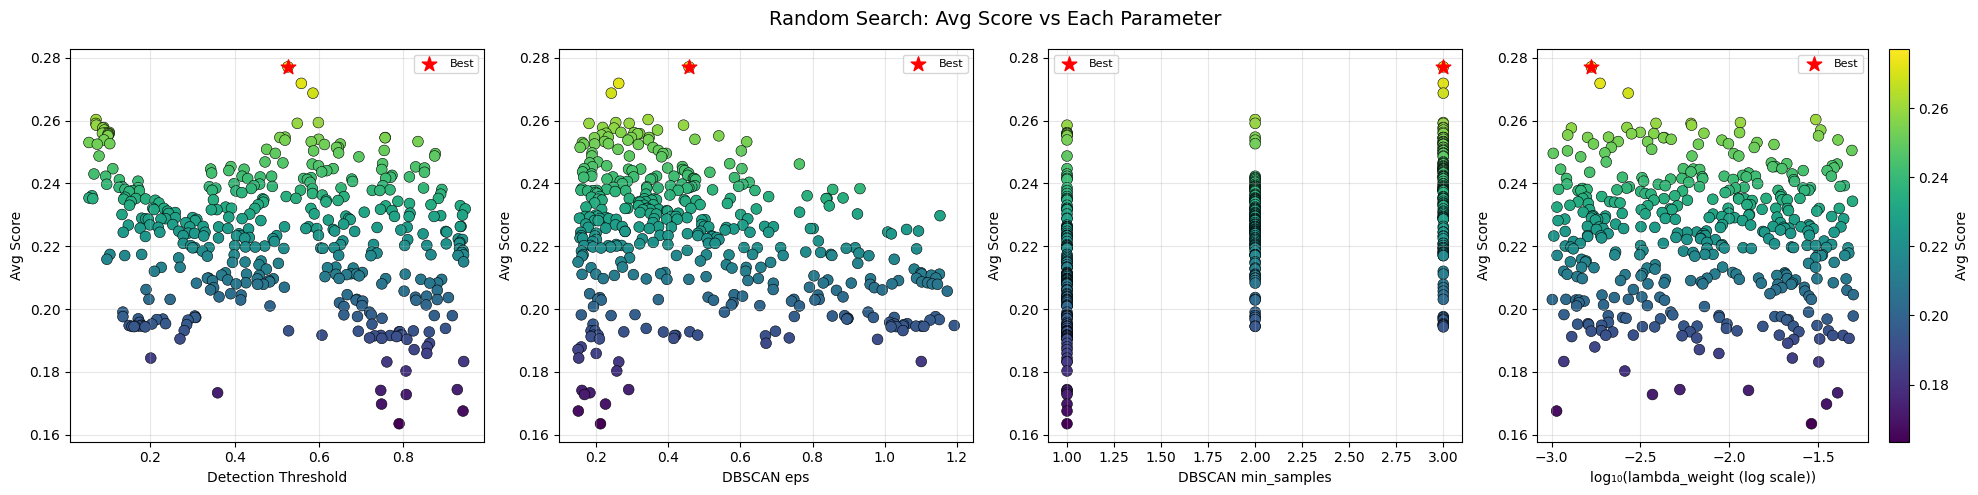

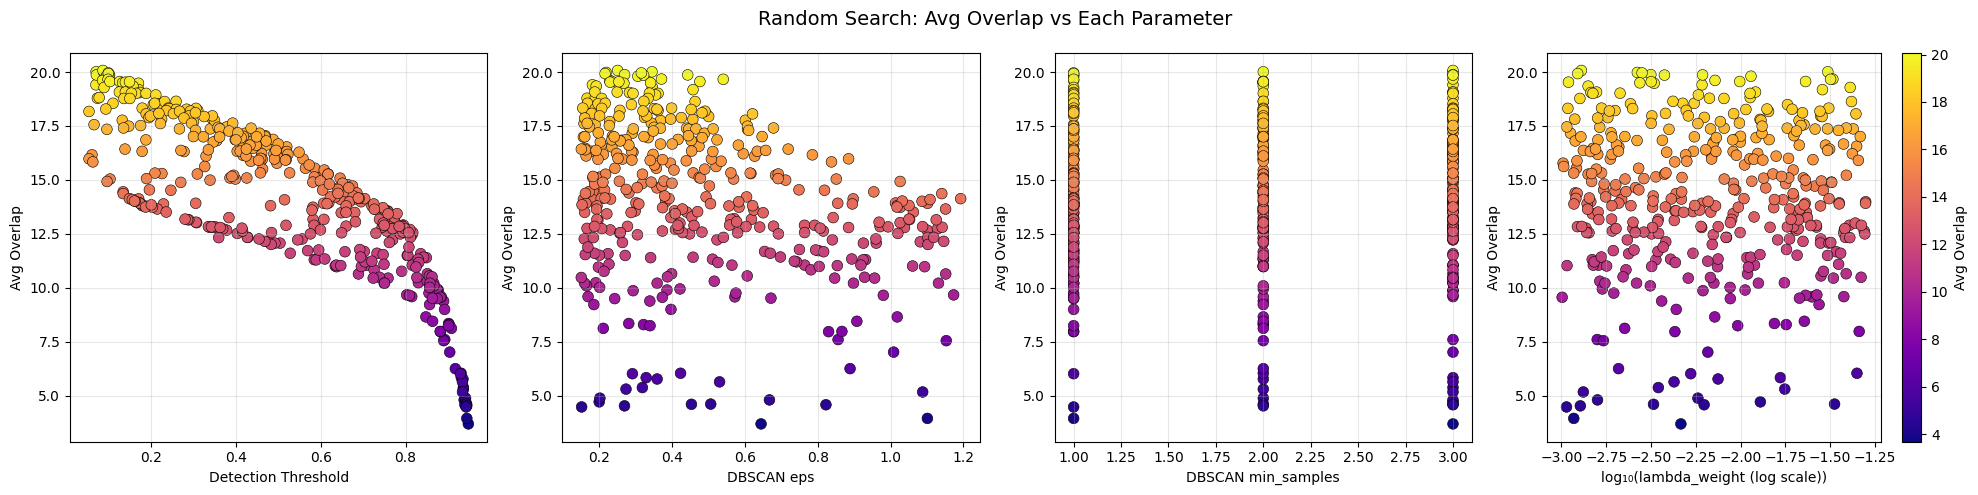

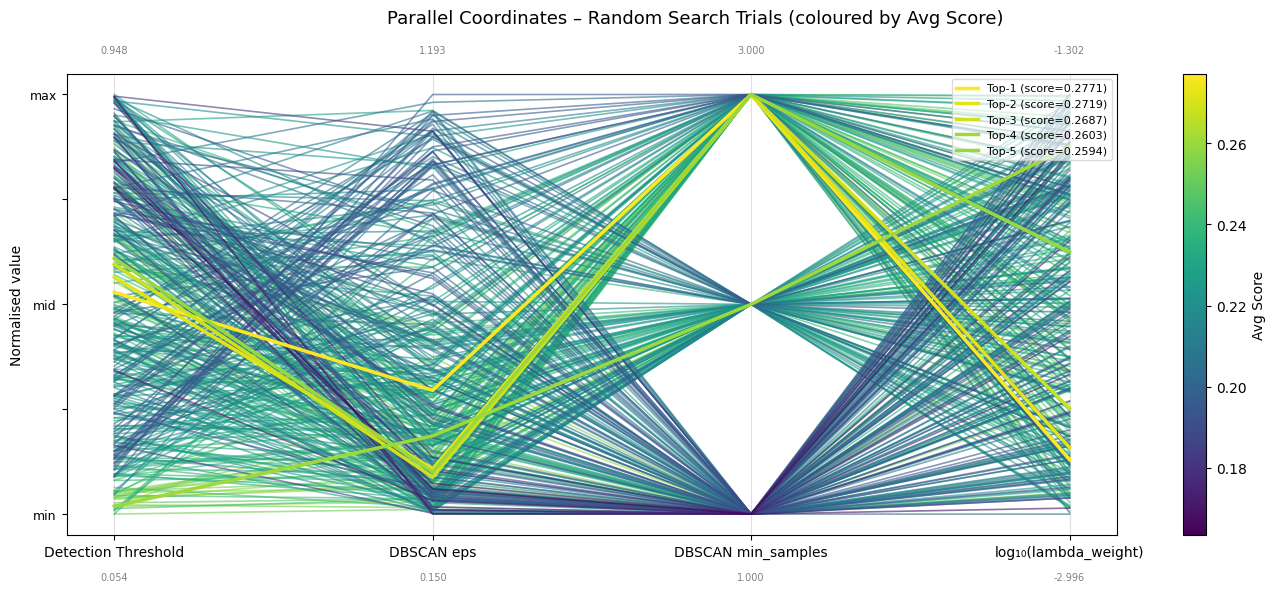


Top-30 parameter combinations by Avg Score:
    Threshold    Eps  MinSamples  LambdaWeight  Avg_Score  Avg_Overlap  Count
0      0.5268 0.4578           3        0.0017     0.2771      15.3265     98
1      0.5586 0.2632           3        0.0019     0.2719      15.9694     98
2      0.5861 0.2426           3        0.0027     0.2687      15.5408     98
3      0.0709 0.3447           2        0.0307     0.2603      20.0102     98
4      0.5991 0.2550           3        0.0116     0.2594      14.9388     98
5      0.5490 0.2922           2        0.0039     0.2591      16.2857     98
6      0.0704 0.1809           3        0.0061     0.2591      19.4082     98
7      0.0716 0.4427           1        0.0061     0.2585      19.8673     98
8      0.0891 0.2188           3        0.0027     0.2578      19.9796     98
9      0.0870 0.2502           3        0.0013     0.2576      20.0714     98
10     0.0904 0.3707           3        0.0327     0.2570      19.6735     98
11     0.1025 0.269

In [49]:
# visualize random search results
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.colors import Normalize

params_cols = ['Threshold', 'Eps', 'MinSamples', 'LambdaWeight']
param_labels = {
    'Threshold':    'Detection Threshold',
    'Eps':          'DBSCAN eps',
    'MinSamples':   'DBSCAN min_samples',
    'LambdaWeight': 'lambda_weight (log scale)',
}

scores = df_summary_sorted['Avg_Score'].values
norm = Normalize(vmin=scores.min(), vmax=scores.max())
cmap = cm.viridis

# ── 1. Scatter: Avg_Score vs each individual parameter ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Random Search: Avg Score vs Each Parameter', fontsize=14)

for ax, col in zip(axes, params_cols):
    x = df_summary_sorted[col].values
    colors = cmap(norm(scores))
    
    if col == 'LambdaWeight':
        ax.scatter(np.log10(x), scores, c=colors, s=60, edgecolors='k', linewidths=0.4)
        ax.set_xlabel('log₁₀(' + param_labels[col] + ')', fontsize=10)
    else:
        ax.scatter(x, scores, c=colors, s=60, edgecolors='k', linewidths=0.4)
        ax.set_xlabel(param_labels[col], fontsize=10)
    
    ax.set_ylabel('Avg Score', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Mark the best point
    best_x = df_summary_sorted[col].iloc[0]
    best_s = scores[0]
    ax_x = np.log10(best_x) if col == 'LambdaWeight' else best_x
    ax.scatter([ax_x], [best_s], c='red', s=120, marker='*', zorder=5, label='Best')
    ax.legend(fontsize=8)

plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes[-1], label='Avg Score')
plt.tight_layout()
plt.show()

# ── 2. Scatter: Avg_Overlap vs each individual parameter ────────────────────
overlaps = df_summary_sorted['Avg_Overlap'].values
norm_ov = Normalize(vmin=overlaps.min(), vmax=overlaps.max())
cmap_ov = cm.plasma

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Random Search: Avg Overlap vs Each Parameter', fontsize=14)

for ax, col in zip(axes, params_cols):
    x = df_summary_sorted[col].values
    colors = cmap_ov(norm_ov(overlaps))
    if col == 'LambdaWeight':
        ax.scatter(np.log10(x), overlaps, c=colors, s=60, edgecolors='k', linewidths=0.4)
        ax.set_xlabel('log₁₀(' + param_labels[col] + ')', fontsize=10)
    else:
        ax.scatter(x, overlaps, c=colors, s=60, edgecolors='k', linewidths=0.4)
        ax.set_xlabel(param_labels[col], fontsize=10)
    ax.set_ylabel('Avg Overlap', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.colorbar(cm.ScalarMappable(norm=norm_ov, cmap=cmap_ov), ax=axes[-1], label='Avg Overlap')
plt.tight_layout()
plt.show()

# ── 3. Parallel coordinates (normalised) coloured by Avg_Score ──────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Parallel Coordinates – Random Search Trials (coloured by Avg Score)', fontsize=13)

# Columns to show (use log for LambdaWeight)
pc_data = df_summary_sorted[params_cols].copy()
pc_data['LambdaWeight'] = np.log10(pc_data['LambdaWeight'])
pc_labels = [param_labels[c] for c in params_cols]
pc_labels[-1] = 'log₁₀(lambda_weight)'

# Normalise each axis to [0, 1] for display
pc_norm = pc_data.copy()
for col in pc_data.columns:
    mn, mx = pc_data[col].min(), pc_data[col].max()
    if mx > mn:
        pc_norm[col] = (pc_data[col] - mn) / (mx - mn)
    else:
        pc_norm[col] = 0.5

n_axes = len(params_cols)
xs = list(range(n_axes))

for i, row in pc_norm.iterrows():
    color = cmap(norm(scores[i]))
    ax.plot(xs, row.values, color=color, alpha=0.6, linewidth=1.2)

# Highlight top-5 trials
for rank in range(min(5, len(df_summary_sorted))):
    color = cmap(norm(scores[rank]))
    ax.plot(xs, pc_norm.iloc[rank].values, color=color, linewidth=2.5,
            alpha=1.0, label=f'Top-{rank+1} (score={scores[rank]:.4f})')

# Axis decorations
ax.set_xticks(xs)
ax.set_xticklabels(pc_labels, fontsize=10)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['min', '', 'mid', '', 'max'], fontsize=9)
ax.set_ylabel('Normalised value', fontsize=10)
ax.grid(axis='x', alpha=0.4)
# Add actual value annotations on each axis
for j, col in enumerate(params_cols):
    mn = pc_data[col].min()
    mx = pc_data[col].max()
    ax.text(j, -0.08, f'{mn:.3f}', ha='center', va='top', fontsize=7, color='grey', transform=ax.get_xaxis_transform())
    ax.text(j,  1.04, f'{mx:.3f}', ha='center', va='bottom', fontsize=7, color='grey', transform=ax.get_xaxis_transform())

plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Avg Score')
ax.legend(loc='upper right', fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

# ── 4. Top-30 table ──────────────────────────────────────────────────────────
print("\nTop-30 parameter combinations by Avg Score:")
print(df_summary_sorted.head(30).to_string(index=True))


In [50]:
# Clean up: Close ABZ resolver connection
# Run this when you're done with all evaluations
if 'abz_resolver' in globals():
    cache_stats = abz_resolver.get_cache_stats()
    print(f"ABZ Resolver Cache Stats:")
    print(f"  Cached signs: {cache_stats['cached_signs']}")
    print(f"  Found in DB: {cache_stats['found']}")
    print(f"  Not found: {cache_stats['not_found']}")
    
    abz_resolver.close()
    print("\nABZ resolver connection closed")

ABZ Resolver Cache Stats:
  Cached signs: 1015
  Found in DB: 389
  Not found: 626

ABZ resolver connection closed
